# Clasificacion de Sentimiento - Rest-Mex 2025
## Bi-LSTM + FastText + Optuna | Division 70/15/15

Pipeline completo para clasificacion de polaridad (1-5) sobre resenas turisticas en espanol.

**Arquitectura:** Bi-LSTM con embeddings FastText preentrenados (cc.es.300.bin)  
**Optimizacion:** Optuna con TPE  
**Metrica principal:** Macro F1  
**Division:** Train 70% | Validacion 15% | Test interno 15%

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import fasttext
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader

C:\Users\AaronMCC\miniconda3\envs\clas_Rest-Mex2025\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuracion General

In [2]:
# --- Rutas de entrada ---
FASTTEXT_PATH = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\dataset\cc.es.300.bin'
DATA_PATH     = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\dataset\rest_mex_cleaned_v2.pkl'

# --- Rutas de salida ---
OUTPUT_DIR      = r'C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados'
BEST_MODEL_PATH = OUTPUT_DIR + r'\best_model.pt'
CSV_HISTORY     = OUTPUT_DIR + r'\training_history.csv'
CSV_OPTUNA      = OUTPUT_DIR + r'\optuna_results.csv'
PLOT_CURVES     = OUTPUT_DIR + r'\curvas_entrenamiento.png'
PLOT_CONFUSION  = OUTPUT_DIR + r'\confusion_matrix.png'

# --- Division del dataset ---
TRAIN_SIZE  = 0.70
VAL_SIZE    = 0.15
TEST_SIZE   = 0.15
RANDOM_SEED = 42

# --- Hiperparametros de entrenamiento ---
EPOCHS_OPTUNA = 10      # Epocas por trial de Optuna
EPOCHS_FINAL  = 20      # Epocas del entrenamiento final
N_TRIALS      = 30      # Trials de Optuna
BATCH_SIZE    = 256
MAX_FEATURES  = 100_000
EMBED_DIM     = 300

# --- Nombres de clases ---
CLASS_NAMES = ['Muy negativo', 'Negativo', 'Neutral', 'Positivo', 'Muy positivo']

# --- Semilla y dispositivo ---
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

Dispositivo: cuda


## 3. Carga de Datos

In [3]:
print('Cargando dataset...')
df = pd.read_pickle(DATA_PATH)
df['label'] = df['Polarity'].astype(int) - 1  # Rango 0-4
print(f'Total de ejemplos: {len(df):,}')
df.head()

Cargando dataset...
Total de ejemplos: 207,688


,Title,Review,Polarity,Town,Region,Type,text_raw,text_combined,label
0,Mi Lugar Favorito!!!!,Excelente lugar para comer y pasar una buena n...,5.0,Sayulita,Nayarit,Restaurant,Mi Lugar Favorito!!!! Excelente lugar para com...,mi lugar favorito excelente lugar para comer y...,4
1,lugares interesantes para visitar,"andar mucho, así que un poco difícil para pers...",4.0,Tulum,QuintanaRoo,Attractive,"lugares interesantes para visitar andar mucho,...",lugares interesantes para visitar andar mucho ...,3
2,No es el mismo Dreams,"Es nuestra cuarta visita a Dreams Tulum, elegi...",3.0,Tulum,QuintanaRoo,Hotel,No es el mismo Dreams Es nuestra cuarta visit...,no es el mismo dreams es nuestra cuarta visita...,2
3,un buen panorama cerca de CancÃºn,"Estando en CancÃºn, fuimos al puerto y tomamos...",4.0,Isla_Mujeres,QuintanaRoo,Attractive,un buen panorama cerca de CancÃºn Estando en C...,un buen panorama cerca de cancn estando en can...,3
4,El mejor,Es un lugar antiguo y por eso me encanto tiene...,5.0,Patzcuaro,Michoacan,Hotel,El mejor Es un lugar antiguo y por eso me enca...,el mejor es un lugar antiguo y por eso me enca...,4


## 4. Division del Dataset 70 / 15 / 15

1. Separar 70% train y 30% temporal
2. Dividir el temporal en 15% val y 15% test

In [4]:
train_df, temp_df = train_test_split(
    df,
    test_size=VAL_SIZE + TEST_SIZE,
    stratify=df['label'],
    random_state=RANDOM_SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    stratify=temp_df['label'],
    random_state=RANDOM_SEED
)

print(f'Train: {len(train_df):,} ({100*len(train_df)/len(df):.1f}%)')
print(f'Val:   {len(val_df):,} ({100*len(val_df)/len(df):.1f}%)')
print(f'Test:  {len(test_df):,} ({100*len(test_df)/len(df):.1f}%)')

# Distribucion de clases por particion
print('\nDistribucion de clases:')
for nombre, subset in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = subset['label'].value_counts(normalize=True).sort_index()
    print(f'  {nombre}: {dict(round(dist*100, 1))}')

Train: 145,381 (70.0%)
Val:   31,153 (15.0%)
Test:  31,154 (15.0%)

Distribucion de clases:
  Train: {0: 2.6, 1: 2.6, 2: 7.5, 3: 21.7, 4: 65.6}
  Val: {0: 2.6, 1: 2.6, 2: 7.5, 3: 21.7, 4: 65.6}
  Test: {0: 2.6, 1: 2.6, 2: 7.5, 3: 21.7, 4: 65.6}


## 5. Embeddings FastText

> El vocabulario y la matriz de embeddings se construyen **solo con train**


In [5]:
print('Cargando modelo FastText...')
ft = fasttext.load_model(FASTTEXT_PATH)

def build_vocab_and_matrix(texts, ft_model, max_features=MAX_FEATURES):
    counts = Counter()
    for text in texts:
        counts.update(text.split())

    vocab = {word: i + 2 for i, (word, _) in enumerate(counts.most_common(max_features))}
    vocab['<PAD>'] = 0
    vocab['<OOV>'] = 1

    embedding_matrix = np.zeros((len(vocab), EMBED_DIM))
    for word, i in vocab.items():
        if i > 1:
            embedding_matrix[i] = ft_model.get_word_vector(word)
        elif i == 1:
            embedding_matrix[i] = np.random.normal(scale=0.6, size=(EMBED_DIM,))

    return vocab, torch.tensor(embedding_matrix, dtype=torch.float32)

vocab, embedding_matrix = build_vocab_and_matrix(train_df['text_combined'], ft)
del ft
print(f'Vocabulario (solo train): {len(vocab):,} tokens')

Cargando modelo FastText...
Vocabulario (solo train): 100,002 tokens


## 6. Tokenizacion y DataLoaders

> `MAX_LEN` se calcula **solo sobre train** (percentil 95).

In [6]:
MAX_LEN = int(train_df['text_combined'].str.split().str.len().quantile(0.95))
print(f'Longitud maxima de secuencia (p95 train): {MAX_LEN}')

def tokenize_text(text, vocab, max_len):
    tokens = [vocab.get(w, 1) for w in text.split()[:max_len]]
    return tokens + [0] * (max_len - len(tokens))

class RestMexDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.sequences = [tokenize_text(t, vocab, max_len) for t in texts]
        self.labels = labels.values

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

train_ds = RestMexDataset(train_df['text_combined'], train_df['label'], vocab, MAX_LEN)
val_ds   = RestMexDataset(val_df['text_combined'],   val_df['label'],   vocab, MAX_LEN)
test_ds  = RestMexDataset(test_df['text_combined'],  test_df['label'],  vocab, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# Class weights calculados SOLO sobre train
weights       = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f'Class weights: {dict(enumerate(weights.round(3)))}')

Longitud maxima de secuencia (p95 train): 146
Class weights: {0: 7.644, 1: 7.574, 2: 2.678, 3: 0.923, 4: 0.305}


## 7. Arquitectura Bi-LSTM

```
Texto tokenizado
      ↓
nn.Embedding (FastText 300d, entrenable o congelado)
      ↓
SpatialDropout
      ↓
Bi-LSTM (hidden_dim, num_layers, bidireccional)
      ↓
AvgPool + MaxPool → Concatenacion
      ↓
Linear → 5 clases
```

In [7]:
class SpatialDropout(nn.Dropout2d):
    def forward(self, x):
        x = x.unsqueeze(2)
        x = x.permute(0, 3, 2, 1)
        x = super().forward(x)
        x = x.permute(0, 3, 2, 1)
        x = x.squeeze(2)
        return x

class BiLSTMClassifier(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_layers, dropout, freeze):
        super().__init__()
        self.embedding       = nn.Embedding.from_pretrained(embedding_matrix, freeze=freeze)
        self.spatial_dropout = SpatialDropout(dropout)
        self.lstm            = nn.LSTM(
            EMBED_DIM, hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim * 2 * 2, 5)

    def forward(self, x):
        x = self.embedding(x)
        x = self.spatial_dropout(x)
        lstm_out, _ = self.lstm(x)
        avg_pool = torch.mean(lstm_out, 1)
        max_pool, _ = torch.max(lstm_out, 1)
        combined = torch.cat((avg_pool, max_pool), 1)
        return self.fc(combined)

print('Arquitectura definida.')

Arquitectura definida.


## 8. Funciones de Entrenamiento y Evaluacion

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
    return total_loss / len(loader), 100 * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total
    avg_f1   = f1_score(all_labels, all_preds, average='macro') * 100
    return avg_loss, accuracy, avg_f1, all_preds, all_labels

def compute_full_metrics(labels, preds):
    return {
        'macro_f1':        f1_score(labels, preds, average='macro') * 100,
        'accuracy':        accuracy_score(labels, preds) * 100,
        'macro_precision': precision_score(labels, preds, average='macro', zero_division=0) * 100,
        'macro_recall':    recall_score(labels, preds, average='macro', zero_division=0) * 100,
    }

def print_metrics(metrics, titulo):
    print(f'\n{titulo}')
    print(f'  Macro F1:        {metrics["macro_f1"]:.2f}%')
    print(f'  Accuracy:        {metrics["accuracy"]:.2f}%')
    print(f'  Macro Precision: {metrics["macro_precision"]:.2f}%')
    print(f'  Macro Recall:    {metrics["macro_recall"]:.2f}%')

def plot_confusion_matrix(labels, preds, titulo, save_path):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(titulo)
    plt.ylabel('Etiqueta real')
    plt.xlabel('Etiqueta predicha')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f'Matriz guardada en: {save_path}')

print('Funciones definidas.')

Funciones definidas.


## 9. Busqueda de Hiperparametros con Optuna

El primer trial usa los mejores valores conocidos como punto de partida.

In [9]:
def objective(trial):
    hidden_dim   = trial.suggest_categorical('hidden_dim', [64, 128, 256])
    num_layers   = trial.suggest_int('num_layers', 1, 2)
    dropout      = trial.suggest_float('dropout', 0.2, 0.6)
    lr           = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    freeze       = trial.suggest_categorical('freeze', [True, False])

    model     = BiLSTMClassifier(embedding_matrix, hidden_dim, num_layers, dropout, freeze).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    best_f1, no_improve, patience = 0.0, 0, 3

    for epoch in range(1, EPOCHS_OPTUNA + 1):
        train_epoch(model, train_loader, optimizer, criterion)
        _, _, v_f1, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(v_f1)
        if v_f1 > best_f1:
            best_f1, no_improve = v_f1, 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    return best_f1

print(f'Iniciando busqueda de hiperparametros ({N_TRIALS} trials)...')
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize')

study.enqueue_trial({
    'hidden_dim': 128,
    'num_layers': 2,
    'dropout': 0.25562306762754566,
    'lr': 0.002494998277098372,
    'weight_decay': 2.3371875941792994e-05,
    'freeze': True
})

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f'\nMejor V-F1 (Optuna): {study.best_value:.2f}%')
print('Mejores hiperparametros:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

optuna_df = study.trials_dataframe()
optuna_df.to_csv(CSV_OPTUNA, index=False)
print(f'Resultados Optuna guardados en: {CSV_OPTUNA}')

Iniciando busqueda de hiperparametros (30 trials)...


Best trial: 0. Best value: 57.7365: 100%|█████████████████████████████████| 30/30 [2:13:14<00:00, 266.47s/it]


Mejor V-F1 (Optuna): 57.74%
Mejores hiperparametros:
  hidden_dim: 128
  num_layers: 2
  dropout: 0.25562306762754566
  lr: 0.002494998277098372
  weight_decay: 2.3371875941792994e-05
  freeze: True
Resultados Optuna guardados en: C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\optuna_results.csv


## 10. Entrenamiento Final

Se entrena con los mejores hiperparametros encontrados por Optuna.
El mejor modelo segun V-F1 se guarda en disco en cada mejora.

In [10]:
best = study.best_params

model_final     = BiLSTMClassifier(
    embedding_matrix,
    hidden_dim  = best['hidden_dim'],
    num_layers  = best['num_layers'],
    dropout     = best['dropout'],
    freeze      = best['freeze']
).to(device)

criterion_final = nn.CrossEntropyLoss(weight=class_weights)
optimizer_final = optim.Adam(model_final.parameters(), lr=best['lr'], weight_decay=best['weight_decay'])
scheduler_final = optim.lr_scheduler.ReduceLROnPlateau(optimizer_final, mode='max', factor=0.5, patience=2)

history = {
    'epoch': [], 'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []
}

best_val_f1, best_epoch = 0.0, 0
best_preds, best_labels = [], []
no_improve, patience    = 0, 5

print(f'Entrenamiento final ({EPOCHS_FINAL} epocas)...')
print(f'{"Epoca":>5} | {"T-Loss":>7} | {"T-Acc":>7} | {"V-Loss":>7} | {"V-Acc":>7} | {"V-F1":>7} | {"LR":>10}')
print('-' * 75)

for epoch in range(1, EPOCHS_FINAL + 1):
    t_loss, t_acc                        = train_epoch(model_final, train_loader, optimizer_final, criterion_final)
    v_loss, v_acc, v_f1, v_preds, v_lbls = evaluate(model_final, val_loader, criterion_final)

    scheduler_final.step(v_f1)
    current_lr = optimizer_final.param_groups[0]['lr']

    history['epoch'].append(epoch)
    history['train_loss'].append(round(t_loss, 4))
    history['train_acc'].append(round(t_acc, 2))
    history['val_loss'].append(round(v_loss, 4))
    history['val_acc'].append(round(v_acc, 2))
    history['val_f1'].append(round(v_f1, 2))
    history['lr'].append(current_lr)

    print(f'{epoch:>5} | {t_loss:>7.3f} | {t_acc:>6.2f}% | {v_loss:>7.3f} | {v_acc:>6.2f}% | {v_f1:>6.2f}% | LR: {current_lr:.2e}')

    if v_f1 > best_val_f1:
        best_val_f1, best_epoch = v_f1, epoch
        best_preds, best_labels = v_preds, v_lbls
        no_improve = 0
        torch.save(model_final.state_dict(), BEST_MODEL_PATH)
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'Early stopping en epoca {epoch} | Mejor V-F1: {best_val_f1:.2f}%')
            break

# Guardar historial
pd.DataFrame(history).to_csv(CSV_HISTORY, index=False)
print(f'\nHistorial guardado en: {CSV_HISTORY}')

Entrenamiento final (20 epocas)...
Epoca |  T-Loss |   T-Acc |  V-Loss |   V-Acc |    V-F1 |         LR
---------------------------------------------------------------------------
    1 |   1.182 |  53.71% |   0.984 |  67.43% |  51.77% | LR: 2.49e-03
    2 |   0.990 |  63.73% |   0.943 |  66.03% |  51.45% | LR: 2.49e-03
    3 |   0.950 |  65.10% |   0.943 |  67.44% |  54.50% | LR: 2.49e-03
    4 |   0.931 |  65.85% |   0.917 |  67.95% |  53.81% | LR: 2.49e-03
    5 |   0.914 |  66.18% |   0.908 |  71.74% |  55.26% | LR: 2.49e-03
    6 |   0.899 |  66.66% |   0.902 |  70.76% |  56.18% | LR: 2.49e-03
    7 |   0.891 |  67.11% |   0.903 |  67.27% |  52.69% | LR: 2.49e-03
    8 |   0.879 |  67.10% |   0.894 |  68.79% |  54.36% | LR: 2.49e-03
    9 |   0.870 |  67.37% |   0.895 |  70.34% |  54.90% | LR: 1.25e-03
   10 |   0.839 |  68.00% |   0.891 |  70.46% |  54.94% | LR: 1.25e-03
   11 |   0.832 |  68.05% |   0.889 |  66.72% |  54.94% | LR: 1.25e-03
Early stopping en epoca 11 | Mejor V-F1

## 11. Curvas de Entrenamiento

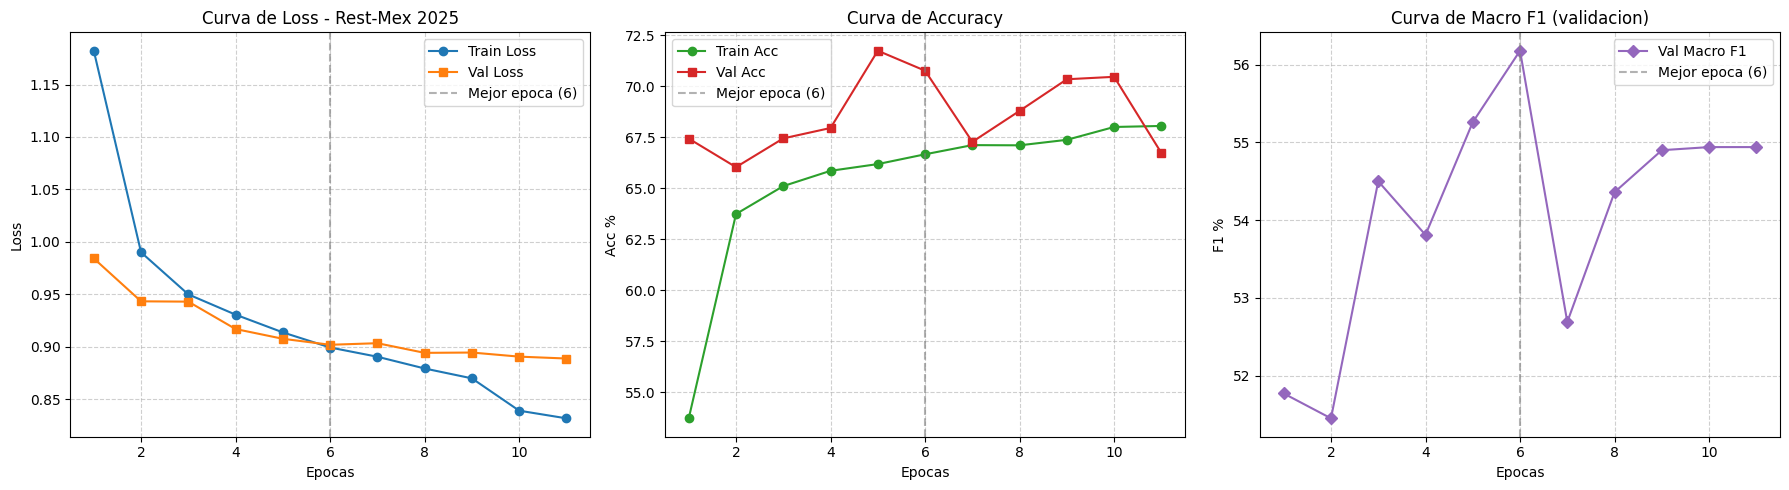

Graficas guardadas en: C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\curvas_entrenamiento.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['epoch'], history['train_loss'], label='Train Loss', color='#1f77b4', marker='o')
axes[0].plot(history['epoch'], history['val_loss'],   label='Val Loss',   color='#ff7f0e', marker='s')
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Mejor epoca ({best_epoch})')
axes[0].set_title('Curva de Loss - Rest-Mex 2025')
axes[0].set_xlabel('Epocas')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(history['epoch'], history['train_acc'], label='Train Acc', color='#2ca02c', marker='o')
axes[1].plot(history['epoch'], history['val_acc'],   label='Val Acc',   color='#d62728', marker='s')
axes[1].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Mejor epoca ({best_epoch})')
axes[1].set_title('Curva de Accuracy')
axes[1].set_xlabel('Epocas')
axes[1].set_ylabel('Acc %')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(history['epoch'], history['val_f1'], label='Val Macro F1', color='#9467bd', marker='D')
axes[2].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Mejor epoca ({best_epoch})')
axes[2].set_title('Curva de Macro F1 (validacion)')
axes[2].set_xlabel('Epocas')
axes[2].set_ylabel('F1 %')
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(PLOT_CURVES, dpi=150)
plt.show()
print(f'Graficas guardadas en: {PLOT_CURVES}')

## 12. Metricas sobre Validacion (Mejor Epoca)

Reporte sobre el conjunto de validacion en la epoca con mejor V-F1.


Metricas de Validacion (Epoca 6)
  Macro F1:        56.18%
  Accuracy:        70.76%
  Macro Precision: 53.28%
  Macro Recall:    60.30%

Reporte de Clasificacion - Validacion (Epoca 6)
              precision    recall  f1-score   support

Muy negativo       0.59      0.72      0.65       815
    Negativo       0.32      0.50      0.39       823
     Neutral       0.41      0.50      0.45      2326
    Positivo       0.47      0.49      0.48      6750
Muy positivo       0.88      0.81      0.84     20439

    accuracy                           0.71     31153
   macro avg       0.53      0.60      0.56     31153
weighted avg       0.73      0.71      0.72     31153



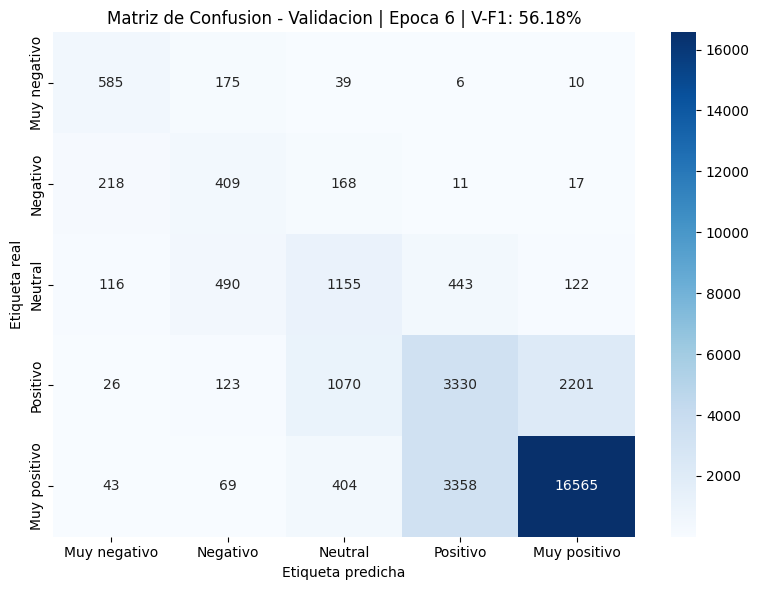

Matriz guardada en: C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\confusion_matrix.png


In [12]:
val_metrics = compute_full_metrics(best_labels, best_preds)
print_metrics(val_metrics, f'Metricas de Validacion (Epoca {best_epoch})')
print(f'\nReporte de Clasificacion - Validacion (Epoca {best_epoch})')
print(classification_report(best_labels, best_preds, target_names=CLASS_NAMES))
plot_confusion_matrix(
    best_labels, best_preds,
    titulo    = f'Matriz de Confusion - Validacion | Epoca {best_epoch} | V-F1: {best_val_f1:.2f}%',
    save_path = PLOT_CONFUSION
)

## 13. Evaluacion Final sobre Test Interno

> Se carga el mejor modelo guardado en disco. El conjunto test **nunca fue visto** durante el entrenamiento ni la busqueda de hiperparametros.

Cargando mejor modelo para evaluacion en test interno...

Metricas Finales sobre Test Interno
  Macro F1:        56.33%
  Accuracy:        70.64%
  Macro Precision: 53.61%
  Macro Recall:    60.22%

Reporte de Clasificacion - Test Interno
              precision    recall  f1-score   support

Muy negativo       0.61      0.71      0.66       815
    Negativo       0.31      0.50      0.38       823
     Neutral       0.43      0.51      0.47      2326
    Positivo       0.46      0.48      0.47      6751
Muy positivo       0.87      0.81      0.84     20439

    accuracy                           0.71     31154
   macro avg       0.54      0.60      0.56     31154
weighted avg       0.73      0.71      0.71     31154



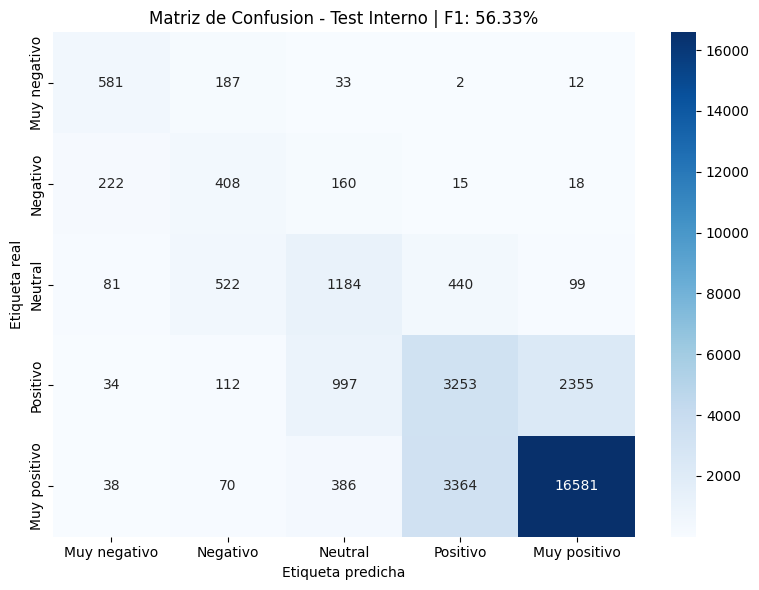

Matriz guardada en: C:\Users\AaronMCC\Documents\Rest-Mex2025\resultados\confusion_matrix_test.png


In [13]:
print('Cargando mejor modelo para evaluacion en test interno...')
model_final.load_state_dict(torch.load(BEST_MODEL_PATH))

_, _, test_f1, test_preds, test_labels = evaluate(model_final, test_loader, criterion_final)
test_metrics = compute_full_metrics(test_labels, test_preds)

print_metrics(test_metrics, 'Metricas Finales sobre Test Interno')
print(f'\nReporte de Clasificacion - Test Interno')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))
plot_confusion_matrix(
    test_labels, test_preds,
    titulo    = f'Matriz de Confusion - Test Interno | F1: {test_metrics["macro_f1"]:.2f}%',
    save_path = PLOT_CONFUSION.replace('.png', '_test.png')
)